# CV intro hometask

In [36]:
import numpy as np
from keras.layers import Input, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D
from keras.layers import AveragePooling2D, MaxPooling2D, Dropout, GlobalMaxPooling2D, GlobalAveragePooling2D
from keras.models import Model, Sequential
from IPython.display import Image, display
import h5py
import matplotlib.pyplot as plt

## Load dataset

In [2]:
def load_dataset(train_path, test_path):
    train_dataset = h5py.File(train_path, "r")
    train_set_x_orig = np.array(train_dataset["train_set_x"][:]) # your train set features
    train_set_y_orig = np.array(train_dataset["train_set_y"][:]) # your train set labels

    test_dataset = h5py.File(test_path, "r")
    test_set_x_orig = np.array(test_dataset["test_set_x"][:]) # your test set features
    test_set_y_orig = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes

    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

In [3]:
train_path = 'data/train_happy.h5'
test_path = 'data/test_happy.h5'
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_dataset(train_path, test_path)

# Normalize image vectors
X_train = X_train_orig/255.
X_test = X_test_orig/255.

# Reshape
Y_train = Y_train_orig.T
Y_test = Y_test_orig.T

print ("number of training examples = " + str(X_train.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(Y_test.shape))

number of training examples = 600
number of test examples = 150
X_train shape: (600, 64, 64, 3)
Y_train shape: (600, 1)
X_test shape: (150, 64, 64, 3)
Y_test shape: (150, 1)


## Model 1

In [4]:
# GRADED FUNCTION: HappyModel

def HappyModel(input_shape):
    """
    Implementation of the HappyModel.

    Arguments:
    input_shape -- shape of the images of the dataset

    Returns:
    model -- a Model() instance in Keras
    """

    ### START CODE HERE ###
    X_input= Input(input_shape)

    # Zero-Padding: pads the border of X_input with zeroes
    X = ZeroPadding2D((3, 3))(X_input)

    # CONV -> BN -> RELU Block applied to X
    X = Conv2D(32, (7, 7), strides = (1, 1), name = 'conv0')(X)
    X = BatchNormalization(axis = 3, name = 'bn0')(X)
    X = Activation('relu')(X)

    # MAXPOOL
    X = MaxPooling2D((2, 2), name='max_pool')(X)

    # FLATTEN X (means convert it to a vector) + FULLYCONNECTED
    X = Flatten()(X)
    X = Dense(1, activation='sigmoid', name='fc')(X)

    # Create model. This creates your Keras model instance, you'll use this instance to train/test the model.
    model = Model(inputs = X_input, outputs = X, name='HappyModel')


    ### END CODE HERE ###

    return model

In [5]:
happy_model = HappyModel(X_train.shape[1:])

happy_model.compile(optimizer = "Adam", loss = "binary_crossentropy", metrics = ["accuracy"])

happy_model.summary()

Model: "HappyModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 70, 70, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv0 (Conv2D)                  │ (None, 64, 64, 32)     │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn0 (BatchNormalization)        │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool (MaxPooling2D)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 1)              │        32,769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,633 (147.00 KB)

 Trainable params: 37,569 (146.75 KB)

 Non-trainable params: 64 (256.00 B)

In [6]:
history = happy_model.fit(X_train, Y_train, epochs = 50, batch_size = 16, validation_data=(X_test, Y_test))
preds = happy_model.evaluate(X_test, Y_test)

print()
print("Loss = " + str(preds[0]))
print("Test Accuracy = " + str(preds[1]))

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7367 - loss: 1.0836 - val_accuracy: 0.5600 - val_loss: 1.4148
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9283 - loss: 0.1949 - val_accuracy: 0.5600 - val_loss: 0.9883
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9583 - loss: 0.1216 - val_accuracy: 0.6000 - val_loss: 0.7903
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9000 - loss: 0.2272 - val_accuracy: 0.9000 - val_loss: 0.3222
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8783 - loss: 0.3899 - val_accuracy: 0.6933 - val_loss: 0.6355
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9333 - loss: 0.1674 - val_accuracy: 0.8733 - val_loss: 0.2874
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9617 - loss: 0.0979 - val_accuracy: 0.9400 - val_loss: 0.2144
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9767 - loss: 0.0733 - val_accuracy: 0.9000 - v

## Train and validation loses

Text(0.5, 1.0, 'Loss Curves')

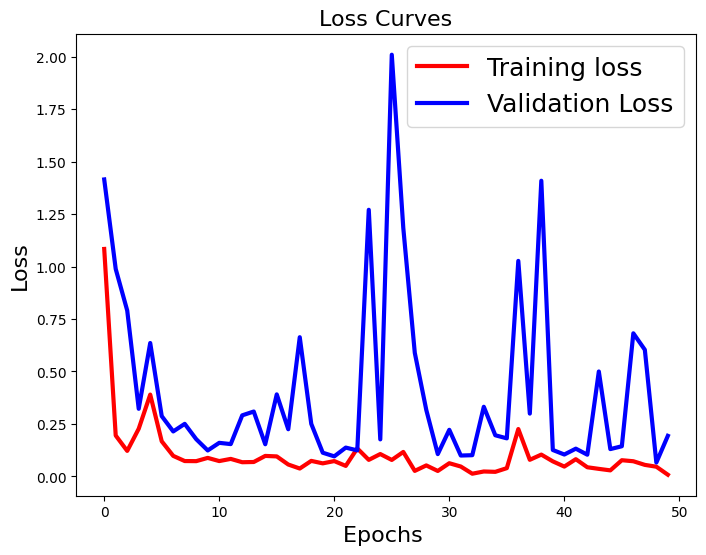

In [7]:
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

## Train and validation accuracies

Text(0.5, 1.0, 'Accuracy Curves')

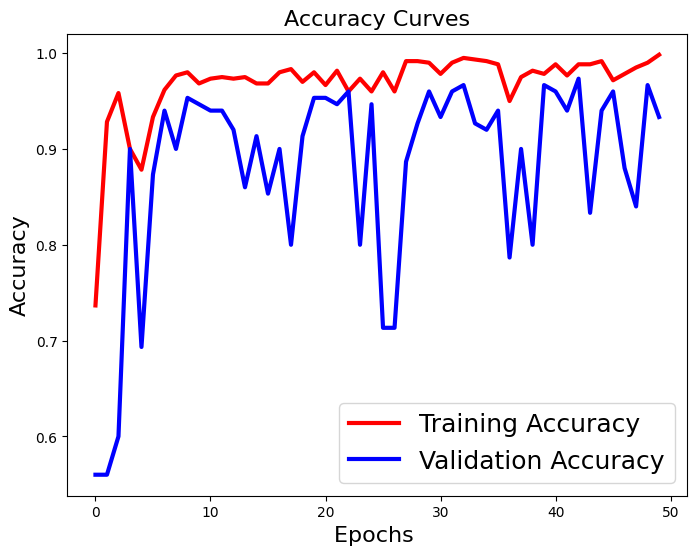

In [12]:
plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)

## Predicts visualization

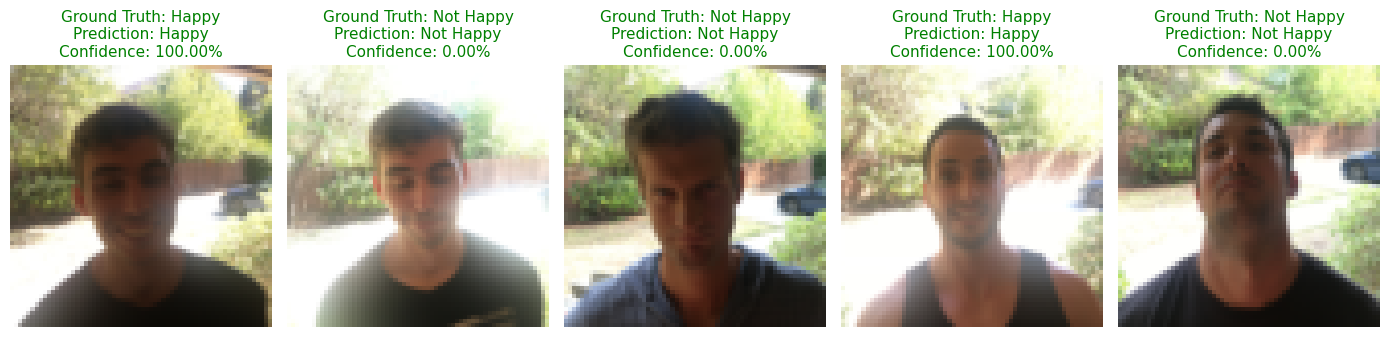

In [27]:
num_samples = 5
random_indices = np.random.choice(X_test.shape[0], num_samples, replace=False)

plt.figure(figsize=(14, 5))

for i, idx in enumerate(random_indices):
    img = X_test[idx]
    true_label = int(Y_test[idx][0])
    img_for_prediction = np.expand_dims(img, axis=0)
    
    pred_prob = happy_model.predict(img_for_prediction, verbose=0)[0][0]
    
    pred_label = 1 if pred_prob > 0.5 else 0

    status_true = "Happy" if true_label == 1 else "Not Happy"
    status_pred = "Happy" if pred_label == 1 else "Not Happy"
    
    title_color = 'green' if true_label == pred_label else 'red'

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img)
    
    plt.title(f"Ground Truth: {status_true}\nPrediction: {status_pred}\nConfidence: {pred_prob:.2%}", 
              color=title_color, fontsize=11)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Model 2: add dropout and more layers

In [37]:
def HappyModel2(input_shape):
    model = Sequential()
    
    model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape))
    model.add(Conv2D(32, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    
    model.add(Dense(1, activation='sigmoid'))

    return model

In [38]:
happy_model2 = HappyModel2(X_train.shape[1:])

happy_model2.compile(optimizer = "Adam", loss = "binary_crossentropy", metrics = ["accuracy"])

happy_model2.summary()

c:\Users\poyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 62, 62, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 31, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,320,097 (5.04 MB)

 Trainable params: 1,320,097 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history2 = happy_model2.fit(X_train, Y_train, epochs = 50, batch_size = 16, validation_data=(X_test, Y_test))
preds2 = happy_model2.evaluate(X_test, Y_test)

print()
print("Loss = " + str(preds2[0]))
print("Test Accuracy = " + str(preds2[1]))

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.4933 - loss: 0.6961 - val_accuracy: 0.5600 - val_loss: 0.6900
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.5217 - loss: 0.6923 - val_accuracy: 0.5533 - val_loss: 0.6762
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.6567 - loss: 0.6387 - val_accuracy: 0.6533 - val_loss: 0.5907
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7400 - loss: 0.5084 - val_accuracy: 0.8733 - val_loss: 0.3260
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8250 - loss: 0.3831 - val_accuracy: 0.8867 - val_loss: 0.2934
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8750 - loss: 0.2938 - val_accuracy: 0.8467 - val_loss: 0.3110
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8833 - loss: 0.2561 - val_accuracy: 0.9200 - val_loss: 0.1966
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9333 - loss: 0.1855 - val_accuracy: 0.9133 - v

## Train and validation loses

Text(0.5, 1.0, 'Loss Curves')

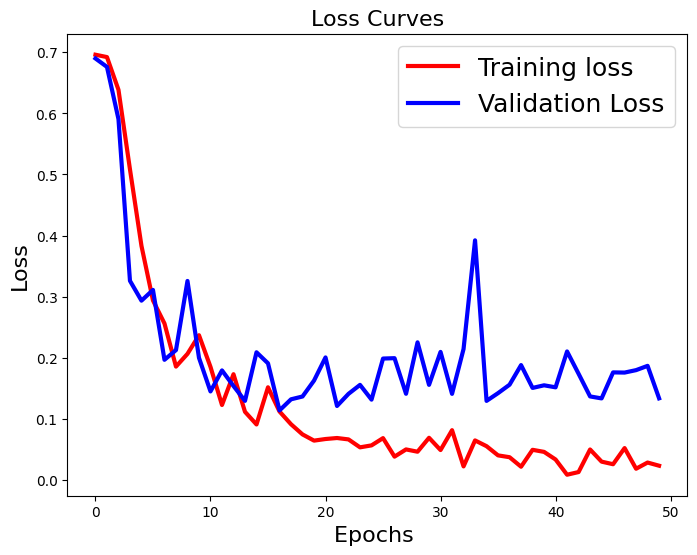

In [40]:
plt.figure(figsize=[8,6])
plt.plot(history2.history['loss'],'r',linewidth=3.0)
plt.plot(history2.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

## Train and validation accuracies

Text(0.5, 1.0, 'Accuracy Curves')

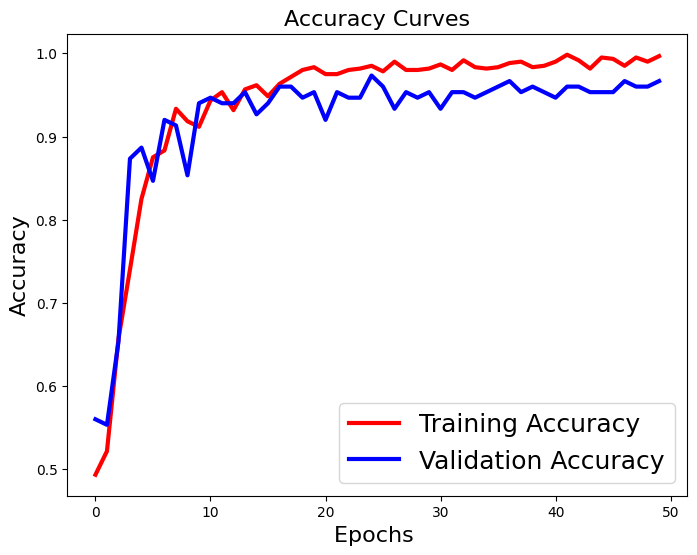

In [41]:
plt.figure(figsize=[8,6])
plt.plot(history2.history['accuracy'],'r',linewidth=3.0)
plt.plot(history2.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)

## Predicts visualization

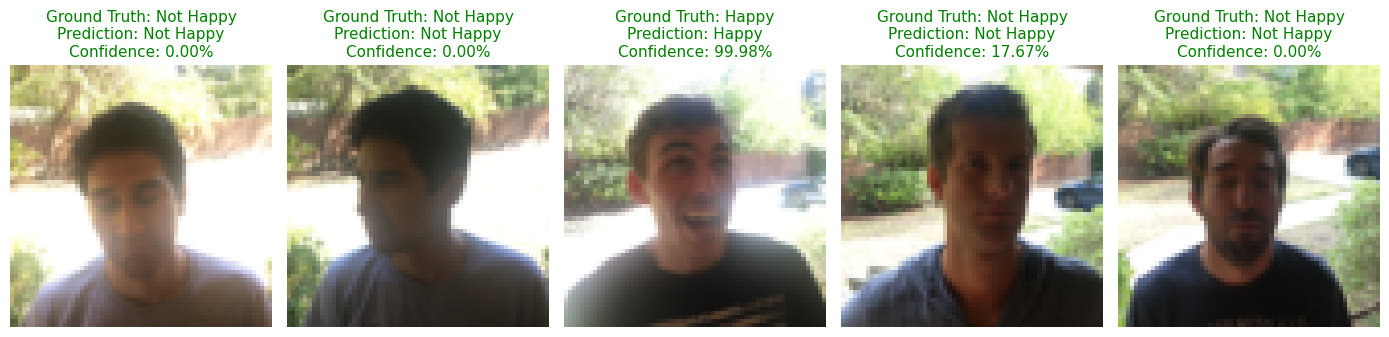

In [46]:
num_samples = 5
random_indices = np.random.choice(X_test.shape[0], num_samples, replace=False)

plt.figure(figsize=(14, 5))

for i, idx in enumerate(random_indices):
    img = X_test[idx]
    true_label = int(Y_test[idx][0])
    img_for_prediction = np.expand_dims(img, axis=0)
    
    pred_prob = happy_model2.predict(img_for_prediction, verbose=0)[0][0]
    
    pred_label = 1 if pred_prob > 0.5 else 0

    status_true = "Happy" if true_label == 1 else "Not Happy"
    status_pred = "Happy" if pred_label == 1 else "Not Happy"
    
    title_color = 'green' if true_label == pred_label else 'red'

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img)
    
    plt.title(f"Ground Truth: {status_true}\nPrediction: {status_pred}\nConfidence: {pred_prob:.2%}", 
              color=title_color, fontsize=11)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Висновок

Як ми можемо побачити з результатів, додавання додаткових шарів та шару Dropout допомогло покращити якість моделі. Вона видає впевненість в 100 відсотків, і якщо подивитись на графіки лузів та точності, можна побачити що перша модель перенавчилась, тоді як друга модель має більш плавні графіки, що свідчить про кращу здатність до узагальнення. 